In [ ]:
"""Elden Ring Boss Dataset Generator

This script scrapes boss entries from the Elden Ring Fandom Wiki. For each boss,
it collects: (1) name, (2) page URL, (3) main image (highest available resolution),
and (4) a short textual description. Images are downloaded to `eldenring_images/`,
and structured metadata is stored in `eldenring_bosses.json`.

"""
import os
import re
import json
import time
import requests
from bs4 import BeautifulSoup

BASE_URL = "https://eldenring.fandom.com"
BOSSES_PAGE = "/wiki/Bosses"
SECTION_HEADER = "List of bosses in Elden Ring"
IMAGE_DIR = "eldenring_images"
OUTPUT_JSON = "eldenring_bosses.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

session = requests.Session()
session.headers.update(HEADERS)

def safe_filename(name, existing_files):
    base = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    filename = base + ".jpg"
    counter = 1
    while filename in existing_files:
        filename = f"{base}_{counter}.jpg"
        counter += 1
    existing_files.add(filename)
    return filename

def get_full_res_image_url(url):
    """Remove '/scale-to-width-down/<number>' from Fandom image URLs to get full-res image"""
    return re.sub(r'/scale-to-width-down/\d+', '', url)

def download_image(url, path):
    try:
        resp = session.get(url, timeout=10)
        resp.raise_for_status()
        with open(path, "wb") as f:
            f.write(resp.content)
        print(f"Downloaded {path}")
    except Exception as e:
        print(f"Failed to download image {url}: {e}")

def extract_description(soup):
    for header_text in ["lore", "description", "overview", "background"]:
        header = soup.find(lambda tag: tag.name in ["h2", "h3"] and header_text in tag.text.lower())
        if header:
            texts = []
            for sib in header.find_next_siblings():
                if sib.name in ["h2", "h3"]:
                    break
                if sib.name == "p":
                    text = sib.get_text(strip=True)
                    if text:
                        texts.append(text)
                if len(texts) >= 3:
                    break
            if texts:
                return "\n\n".join(texts)
    content_div = soup.find("div", {"class": "mw-parser-output"})
    if content_div:
        paragraphs = content_div.find_all("p", recursive=False)
        texts = []
        for p in paragraphs:
            text = p.get_text(strip=True)
            if text:
                texts.append(text)
            if len(texts) >= 3:
                break
        if texts:
            return "\n\n".join(texts)
    return "No description available."

def extract_main_image(soup):
    infobox = soup.find("table", {"class": "infobox"})
    if infobox:
        img = infobox.find("img")
        if img and img.has_attr("src"):
            return img["src"]
    content_div = soup.find("div", {"class": "mw-parser-output"})
    if content_div:
        img = content_div.find("img")
        if img and img.has_attr("src"):
            return img["src"]
    return None

def get_character_data(url):
    full_url = BASE_URL + url
    resp = session.get(full_url)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")

    name_tag = soup.find("h1", {"id": "firstHeading"})
    name = name_tag.text.strip() if name_tag else url.split("/")[-1]

    img_url = extract_main_image(soup)
    if not img_url or img_url.startswith("data:"):
        # Skip placeholder or missing images completely
        return None, None, None

    if img_url.startswith("//"):
        img_url = "https:" + img_url

    img_url = get_full_res_image_url(img_url)
    description = extract_description(soup)

    return name, img_url, description

def scrape_bosses():
    full_url = BASE_URL + BOSSES_PAGE
    resp = session.get(full_url)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")

    rows = soup.select("tr.navbox-row, tr.navbox-row-alt")
    boss_links = []
    for row in rows:
        hlist_div = row.find("div", class_="hlist")
        if not hlist_div:
            continue
        for li in hlist_div.find_all("li"):
            a = li.find("a", href=True)
            if not a:
                continue
            href = a["href"]
            if href.startswith("/wiki/") and not any(x in href for x in ["/wiki/File:", "/wiki/Category:", "/wiki/Help:", "/wiki/Template:"]):
                boss_links.append(href)

    existing_files = set()
    bosses = []
    seen_names = set()

    print(f"Found {len(boss_links)} potential boss links...")

    for href in boss_links:
        data = get_character_data(href)
        if data == (None, None, None):
            print(f"Skipped entry with invalid or placeholder image: {href}")
            continue

        name, img_url, description = data

        if name in seen_names:
            continue
        seen_names.add(name)

        img_filename = safe_filename(name, existing_files)
        img_path = os.path.join(IMAGE_DIR, img_filename)

        try:
            download_image(img_url, img_path)
        except Exception as e:
            print(f"Failed to download image for {name}: {e}")
            img_path = None

        bosses.append({
            "name": name,
            "page_url": BASE_URL + href,
            "image_path": img_path,
            "description": description
        })

        print(f"Scraped: {name}")
        time.sleep(1)  # be polite

    return bosses


    return bosses

def main():
    os.makedirs(IMAGE_DIR, exist_ok=True)
    bosses = scrape_bosses()

    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(bosses, f, indent=2, ensure_ascii=False)

    print(f"Scraped total {len(bosses)} bosses.")

if __name__ == "__main__":
    main()


Found 141 potential boss links...
Downloaded eldenring_images/Starscourge_Radahn.jpg
Scraped: Starscourge Radahn
Downloaded eldenring_images/Radagon_of_the_Golden_Order.jpg
Scraped: Radagon of the Golden Order
Downloaded eldenring_images/God_Devouring_Serpent.jpg
Scraped: God-Devouring Serpent
Downloaded eldenring_images/Godrick_the_Grafted.jpg
Scraped: Godrick the Grafted
Downloaded eldenring_images/Malenia__Blade_of_Miquella.jpg
Scraped: Malenia, Blade of Miquella
Downloaded eldenring_images/Messmer_the_Impaler.jpg
Scraped: Messmer the Impaler
Downloaded eldenring_images/Mohg__Lord_of_Blood.jpg
Scraped: Mohg, Lord of Blood
Downloaded eldenring_images/Morgott__the_Omen_King.jpg
Scraped: Morgott, the Omen King
Downloaded eldenring_images/Astel.jpg
Scraped: Astel
Downloaded eldenring_images/Bayle_the_Dread.jpg
Scraped: Bayle the Dread
Downloaded eldenring_images/Maliketh__the_Black_Blade.jpg
Scraped: Maliketh, the Black Blade
Downloaded eldenring_images/Commander_Gaius.jpg
Scraped: Comm

In [ ]:
import os
import re
import json
import time
import random
import requests
from bs4 import BeautifulSoup

BASE_URL = "https://eldenring.fandom.com"
BOSSES_PAGE = "/wiki/Bosses"
SECTION_HEADER = "List of bosses in Elden Ring"
IMAGE_DIR = "eldenring_images"
OUTPUT_JSON = "eldenring_bosses.json"

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 Safari/605.1.15",
]

def get_headers():
    return {
        "User-Agent": random.choice(USER_AGENTS),
        "Accept-Language": random.choice(["en-US,en;q=0.9", "en-GB,en;q=0.8"]),
        "Accept-Encoding": "gzip, deflate, br",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Connection": "keep-alive",
        "Referer": BASE_URL,
        "DNT": "1",
        "Upgrade-Insecure-Requests": "1"
    }

session = requests.Session()

def fetch(url, retries=5):
    for attempt in range(retries):
        try:
            session.headers.clear()
            session.headers.update(get_headers())

            if random.random() < 0.2:
                session.get(BASE_URL, timeout=10)

            resp = session.get(url, timeout=10)
            if resp.status_code == 403:
                wait = random.uniform(5, 12)
                print(f"403 blocked on {url} — sleeping {wait:.1f}s before retry {attempt+1}/{retries}")
                time.sleep(wait)
                continue
            if resp.status_code == 404:
                print(f"404 Not Found on {url}")
                return None
            resp.raise_for_status()
            return resp
        except requests.RequestException as e:
            wait = random.uniform(3, 8)
            print(f"Error fetching {url}: {e} (attempt {attempt+1}/{retries})")
            time.sleep(wait)
    print(f"Failed to fetch {url} after {retries} retries.")
    return None

def safe_filename(name, existing_files):
    base = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    filename = base + ".jpg"
    counter = 1
    while filename in existing_files:
        filename = f"{base}_{counter}.jpg"
        counter += 1
    existing_files.add(filename)
    return filename

def get_full_res_image_url(url):
    return re.sub(r'/scale-to-width-down/\d+', '', url)

def download_image(url, path):
    resp = fetch(url, retries=2)
    if resp is None:
        print(f"Failed to download image {url}")
        return False
    try:
        with open(path, "wb") as f:
            f.write(resp.content)
        print(f"Downloaded {path}")
        return True
    except Exception as e:
        print(f"Failed saving image {url}: {e}")
        return False

def extract_description(soup):
    for header_text in ["lore", "description", "overview", "background"]:
        header = soup.find(lambda tag: tag.name in ["h2", "h3"] and header_text in tag.text.lower())
        if header:
            texts = []
            for sib in header.find_next_siblings():
                if sib.name in ["h2", "h3"]:
                    break
                if sib.name == "p":
                    text = sib.get_text(strip=True)
                    if text:
                        texts.append(text)
                if len(texts) >= 3:
                    break
            if texts:
                return "\n\n".join(texts)
    content_div = soup.find("div", {"class": "mw-parser-output"})
    if content_div:
        paragraphs = content_div.find_all("p", recursive=False)
        texts = []
        for p in paragraphs:
            text = p.get_text(strip=True)
            if text:
                texts.append(text)
            if len(texts) >= 3:
                break
        if texts:
            return "\n\n".join(texts)
    return "No description available."

def extract_main_image(soup):
    infobox = soup.find("table", {"class": "infobox"})
    if infobox:
        imgs = infobox.find_all("img")
        for img in imgs:
            if img.has_attr("src") and not img["src"].startswith("data:"):
                return img["src"]
    content_div = soup.find("div", {"class": "mw-parser-output"})
    if content_div:
        imgs = content_div.find_all("img")
        for img in imgs:
            if img.has_attr("src") and not img["src"].startswith("data:"):
                return img["src"]
    return None

def get_character_data(url):
    full_url = BASE_URL + url
    resp = fetch(full_url)
    if resp is None:
        return None, None, None

    soup = BeautifulSoup(resp.text, "html.parser")
    name_tag = soup.find("h1", {"id": "firstHeading"})
    name = name_tag.text.strip() if name_tag else url.split("/")[-1]

    img_url = extract_main_image(soup)
    if not img_url or img_url.startswith("data:"):
        return None, None, None

    if img_url.startswith("//"):
        img_url = "https:" + img_url

    img_url = get_full_res_image_url(img_url)
    description = extract_description(soup)

    return name, img_url, description

def scrape_bosses():
    full_url = BASE_URL + BOSSES_PAGE
    resp = fetch(full_url)
    if resp is None:
        print(f"Failed to load {full_url}")
        return []

    soup = BeautifulSoup(resp.text, "html.parser")

    header = soup.find(lambda tag: tag.name in ["h2", "h3"] and SECTION_HEADER.lower() in tag.text.lower())
    if not header:
        print(f"Header '{SECTION_HEADER}' not found on {BOSSES_PAGE}")
        return []

    container = None
    sibling = header.find_next_sibling()
    while sibling:
        if sibling.name == "div":
            container = sibling
            break
        sibling = sibling.find_next_sibling()

    if not container:
        print(f"Container div after header '{SECTION_HEADER}' not found")
        return []

    existing_files = set()
    bosses = []
    seen_names = set()

    for ul in container.find_all("ul", recursive=False):
        for li in ul.find_all("li", recursive=False):
            a = li.find("a", href=True)
            if not a:
                continue
            href = a['href']
            if not href.startswith("/wiki/"):
                continue
            if any(prefix in href for prefix in ["/wiki/File:", "/wiki/Category:", "/wiki/Template:", "/wiki/Help:"]):
                continue

            data = get_character_data(href)
            if data == (None, None, None):
                print(f"Skipped entry with invalid or placeholder image: {href}")
                continue

            name, img_url, description = data

            if name in seen_names:
                continue
            seen_names.add(name)

            img_filename = safe_filename(name, existing_files)
            img_path = os.path.join(IMAGE_DIR, img_filename)

            success = download_image(img_url, img_path)
            if not success:
                print(f"Skipping boss {name} due to image download failure.")
                continue

            bosses.append({
                "name": name,
                "page_url": BASE_URL + href,
                "image_path": img_path,
                "description": description
            })

            print(f"Scraped: {name}")
            time.sleep(random.uniform(1, 2))

    return bosses

def main():
    os.makedirs(IMAGE_DIR, exist_ok=True)
    bosses = scrape_bosses()

    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(bosses, f, indent=2, ensure_ascii=False)

    print(f"Scraped total {len(bosses)} bosses.")

if __name__ == "__main__":
    main()


In [ ]:
#RUN THIS TO SET THE API KEY (ALSO ZIPS THE IMAGES FOR DOWNLOAD IF NECESSARY)
import shutil
shutil.make_archive("eldenring_images", 'zip', "eldenring_images")
API_KEY = "SET YOUR API KEY HERE!"


In [ ]:
"""
Elden Ring Image Filtering and Caption Generation Pipeline (CLIP + BLIP-2)

This script performs two-stage automated dataset curation:

1. Content Filtering (CLIP):
   • Each image in ./eldenring_images/ is scored for semantic similarity against
     a fixed Elden Ring–style text prompt using OpenAI CLIP (ViT-B/32).
   • Only the top N% (configurable via TOP_PERCENT) are retained.

2. Descriptive Caption Generation (BLIP-2 FLAN-T5-XL):
   • For each retained image, a structured multi-turn Q/A prompt is used to elicit
     detailed descriptions (appearance, equipment, environment, color, lighting).
   • Responses are concatenated into a single natural-language caption.

Output:
   • Filtered image subset:        ./filtered_images/
   • JSON metadata (filename → {caption, clip_score}): elden_captions.json
"""

import os
import shutil
import torch
import json
from PIL import Image, ImageEnhance
from tqdm import tqdm
from transformers import (
    CLIPProcessor, CLIPModel,
    Blip2Processor, Blip2ForConditionalGeneration
)

FILTERED_FOLDER = "./filtered_images"
OUTPUT_JSON = "elden_captions.json"
TOP_PERCENT = 0.9
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_DIR = "eldenring_images"
BLIP_MODEL_NAME = "Salesforce/blip2-flan-t5-xl"
BATCH_SIZE_CLIP = 16

os.makedirs(FILTERED_FOLDER, exist_ok=True)

torch.cuda.empty_cache()

print("Loading models...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").eval().to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
blip_processor = Blip2Processor.from_pretrained(BLIP_MODEL_NAME)
blip_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP_MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32
).eval()

print("Filtering images with CLIP...")
image_scores = []
clip_text = ["A dark fantasy video game character in ornate armor, in the style of Elden Ring"]

image_paths = [os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]

for i in tqdm(range(0, len(image_paths), BATCH_SIZE_CLIP), desc="CLIP Batching"):
    batch_paths = image_paths[i:i + BATCH_SIZE_CLIP]
    try:
        images = [Image.open(p).convert('RGB') for p in batch_paths]
        inputs = clip_processor(text=clip_text * len(images), images=images, return_tensors="pt", padding=True).to(DEVICE)
        with torch.inference_mode():
            outputs = clip_model(**inputs)
            scores = torch.nn.functional.cosine_similarity(outputs.image_embeds, outputs.text_embeds).cpu().tolist()
        for path, score in zip(batch_paths, scores):
            image_scores.append((os.path.basename(path), score))
    except Exception as e:
        print(f"Error in CLIP batch: {e}")

image_scores.sort(key=lambda x: x[1], reverse=True)
top_images = image_scores[:max(1, int(len(image_scores) * TOP_PERCENT))]
print(f"Selected {len(top_images)} images out of {len(image_scores)}")

print("Generating captions with BLIP-2...")
questions = [
    "What does the character look like (visible features)?",
    "What weapons, tools, or magical items are visible?",
    "What is the armor or clothing, including materials and colors?",
    "What is the environment, including setting, lighting, and mood?",
    "What are the dominant colors and visual effects?"
]

def build_prompt(context, question):
    prompt_parts = [f"Question: {q} Answer: {a}." for q, a in context]
    prompt = " ".join(prompt_parts) + f" Question: {question} Answer:"
    return prompt.strip()


results = {}

for fname, score in tqdm(top_images, desc="BLIP-2 Processing"):
    img_path = os.path.join(IMAGE_DIR, fname)
    out_path = os.path.join(FILTERED_FOLDER, fname)

    try:
        image = Image.open(img_path).convert('RGB')
        image = ImageEnhance.Contrast(image).enhance(1.5)
        if min(image.size) < 256:
            image = image.resize((512, 512), Image.LANCZOS)

        shutil.copy(img_path, out_path)

        context = []
        for question in questions:
            prompt = build_prompt(context, question)
            inputs = blip_processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

            with torch.inference_mode():
                output_ids = blip_model.generate(
                    **inputs,
                    max_new_tokens=60,
                    do_sample=False,
                    num_beams=3,
                    repetition_penalty=1.5
                )

            answer = blip_processor.decode(output_ids[0], skip_special_tokens=True).strip()

            context.append((question, answer))

        full_caption = ", ".join([a for _, a in context])
        results[fname] = {"caption": full_caption, "clip_score": score}

        print(f"Generated caption for {fname}: {full_caption}")

    except Exception as e:
        print(f"Error on {fname}: {e}")
        results[fname] = {"caption": f"ERROR: {str(e)}", "clip_score": score}

    torch.cuda.empty_cache()

with open(OUTPUT_JSON, "w") as f:
    json.dump(results, f, indent=2)

print(f"Done! Images saved to: {FILTERED_FOLDER}")
print(f"Captions saved to: {OUTPUT_JSON}")

In [ ]:
"""
Elden Ring Caption Refinement using OpenAI GPT (gpt-4o-mini)

This script upgrades previously generated image captions (e.g. from BLIP-2) into
high-quality Stable Diffusion training prompts using the OpenAI Chat Completions API.

Process:
    • Loads raw captions from: elden_captions.json  (format: {filename: caption})
    • For each valid caption, constructs an instruction prompt enforcing:
        – Rich visual detail (character, armor, setting, lighting, style, etc.)
        – Single coherent sentence suitable for diffusion model training
        – No formatting artifacts (parentheses, weights, repetition)
    • Sends request to OpenAI
    • Outputs refined captions to: elden_captions_refined.json

Requirements:
    • Environment variable API_KEY must contain a valid API key.
    • Internet connectivity is required for API requests.
"""

import json
import requests

API_KEY = "OPENAI_API_KEY_HERE"
API_URL = "https://api.openai.com/v1/chat/completions"

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {API_KEY}"
}

with open("elden_captions.json", "r") as f:
    captions = json.load(f)

refined = {}

for fname, caption in captions.items():
    if caption == "ERROR":
        continue

    prompt = f"""Improve description for captioning Stable Diffusion.
    Create Stable Diffusion captions for Elden Ring images.
]
Rules:
1. Take the input caption and describe all visual elements fully: character(s), body type, posture, weapons, armor/clothing (materials, colors), environment (setting, lighting, mood), action, interactions, color palette, and art style.
2. Output in **one sentence or paragraph**.
3. Do **not include parentheses, colons, or weight numbers**.
4. Be **more descriptive than just 1–3 words**; include details that would help an AI generate the image accurately.
6. Maintain a natural, coherent phrasing suitable for prompt-based training.
7. Be descriptive and give a caption that makes sense in the context.
8. Make sure you don't repeat words, the captions should be in style for stable diffusion training, try to be descriptive but also have a higher vocabulary.
Keep all relevant information.
GENERATE ONE SENTENCE ONLY.

Description: "{caption}"

Improved:"""

    payload = {
        "model": "gpt-4o-mini",
        "messages": [
            {"role": "system", "content": "You are an assistant and expert that converts image captions into detailed, clean prompts for Stable Diffusion training. ."},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.3
    }

    res = requests.post(API_URL, headers=headers, json=payload)
    if res.status_code != 200:
        print(f"Error on {fname}: {res.status_code} {res.text}")
        continue

    response = res.json()
    try:
        text = response['choices'][0]['message']['content']
        refined_caption = text.split("Improved:")[-1].strip()
        refined[fname] = refined_caption
    except Exception as e:
        print(f"Failed to parse response for {fname}: {e}")
        refined[fname] = caption

# Save output
with open("elden_captions_refined.json", "w") as f:
    json.dump(refined, f, indent=2)

print("Refined captions saved to elden_captions_refined.json")


✅ Refined captions saved to elden_captions_refined.json


In [ ]:
"""
Cleans refined captions by removing wrapping quotes and unescaping characters.
Input:  elden_captions_refined.json
Output: elden_captions_clean.json
"""

import json

with open("elden_captions_refined.json", "r", encoding="utf-8") as f:
    captions = json.load(f)

cleaned = {}
for fname, caption in captions.items():
    if caption.startswith('"') and caption.endswith('"'):
        caption = caption[1:-1]
    caption = caption.replace('\\"', '"')
    cleaned[fname] = caption

with open("elden_captions_clean.json", "w", encoding="utf-8") as f:
    json.dump(cleaned, f, indent=2, ensure_ascii=False)

print("Snimljen fajl bez escape navodnika -> elden_captions_clean.json")


In [ ]:
"""
Full LoRA training script for Stable Diffusion 1.5 on Elden Ring images.

Pipeline summary:
- Loads images and captions into a custom PyTorch dataset with augmentations.
- Applies LoRA adapters to UNet and CLIP text encoder (rank = 16).
- Trains using noise prediction (DDPM) with fp16 and gradient checkpointing.
- Saves LoRA weights and optional sample generations every N steps.
- Exports all outputs and checkpoints as a downloadable ZIP (Colab-compatible).

Key hyperparameters:
MODEL_NAME       = "runwayml/stable-diffusion-v1-5"
MAX_TRAIN_STEPS  = 1500
LEARNING_RATE    = 1e-5
LORA_RANK        = 4
RESOLUTION       = 512
STYLE_PHRASE     = "<elden-ring>"

Modifiable parameters:
IMAGE_DIR = "./eldenring_images" // Change this to your actual images folder
CAPTION_PATH = "./elden_captions.json" // Change this to the caption file you want to use
OUTPUT_DIR = "./lora_output" // Change this to the output folder for your adapters

"""

import os
import json
import random
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from PIL import Image
from tqdm import tqdm
from transformers import CLIPTokenizer, CLIPTextModel
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler, StableDiffusionPipeline
from diffusers.loaders import StableDiffusionLoraLoaderMixin
from diffusers.utils import convert_state_dict_to_diffusers
from diffusers.optimization import get_scheduler
from accelerate import Accelerator
from peft import LoraConfig, get_peft_model_state_dict
import zipfile
from google.colab import files  # Colab-specific

# ---------------- CONFIG ----------------
MODEL_NAME = "runwayml/stable-diffusion-v1-5"
IMAGE_DIR = "./eldenring_images"
CAPTION_PATH = "./elden_captions.json"
OUTPUT_DIR = "./lora_output"
RESOLUTION = 512
BATCH_SIZE = 4
MAX_TRAIN_STEPS = 1500
LEARNING_RATE = 1e-5
LORA_RANK = 4
SAVE_EVERY_STEPS = 200
WARMUP_STEPS = 50
STYLE_TOKEN = "<elden-ring>"
GRAD_CLIP_NORM = 1.0

SAMPLE_PROMPTS = [
    f"A heavily armored knight standing in ancient ruins, dramatic lighting, {STYLE_TOKEN}",
    f"Close-up portrait of a mysterious warrior wearing a tarnished helmet, cinematic atmosphere, {STYLE_TOKEN}",
    f"A lone swordsman walking across a foggy battlefield at dawn, wide shot, {STYLE_TOKEN}"
]

# ---------------- DATASET ----------------
class EldenDataset(Dataset):
    def __init__(self, image_dir, caption_json, tokenizer):
        with open(caption_json, "r") as f:
            self.captions = json.load(f)
        self.image_paths = [
            os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname in self.captions
        ]
        if len(self.image_paths) == 0:
            raise ValueError("No images match captions.")
        self.tokenizer = tokenizer
        self.transform = transforms.Compose([
            transforms.Resize((RESOLUTION, RESOLUTION), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.RandomHorizontalFlip(0.5),
            transforms.ColorJitter(0.3, 0.3, 0.3, 0.15),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        caption = self.captions[os.path.basename(image_path)]
        if isinstance(caption, dict):
            caption = caption.get("refined_caption", caption.get("caption", ""))
        caption = caption.strip()
        if STYLE_TOKEN not in caption:
            caption = caption + ", " + STYLE_TOKEN
        tokenized = self.tokenizer(caption, padding="max_length", truncation=True, max_length=77, return_tensors="pt")
        return {"pixel_values": image, "input_ids": tokenized.input_ids[0]}

# ---------------- ACCELERATOR ----------------
accelerator = Accelerator(mixed_precision="fp16", device_placement=True)
device = accelerator.device

# ---------------- LOAD MODELS ----------------
print("🔄 Loading models...")
tokenizer = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder="vae").to(device)
vae.eval()
vae.enable_slicing()
unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder="unet")

# ---------------- LORA ----------------
unet.add_adapter(LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_RANK, init_lora_weights="gaussian",
    target_modules=["to_k","to_q","to_v","to_out.0","add_k_proj","add_v_proj"], lora_dropout=0.1
))
unet.train()
unet.to(device)
unet.enable_gradient_checkpointing()

text_encoder.add_adapter(LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_RANK, init_lora_weights="gaussian",
    target_modules=["q_proj","k_proj","v_proj","out_proj"], lora_dropout=0.1
))
text_encoder.train()
text_encoder.to(device)
text_encoder.gradient_checkpointing_enable()

# ---------------- SCHEDULER ----------------
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_NAME, subfolder="scheduler")

# ---------------- DATALOADER ----------------
dataset = EldenDataset(IMAGE_DIR, CAPTION_PATH, tokenizer)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# ---------------- OPTIMIZER & LR ----------------
trainable_params = list(filter(lambda p: p.requires_grad, unet.parameters())) + \
                   list(filter(lambda p: p.requires_grad, text_encoder.parameters()))
optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=1e-2)
lr_scheduler = get_scheduler("cosine", optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=MAX_TRAIN_STEPS)

# ---------------- PREPARE WITH ACCELERATOR ----------------
unet, text_encoder, optimizer, dataloader, lr_scheduler = accelerator.prepare(
    unet, text_encoder, optimizer, dataloader, lr_scheduler
)

# ---------------- SAVE & GRID ----------------
def save_lora_and_grid(step):
    print(f"💾 Saving LoRA + generating grid at step {step}...")
    accelerator.wait_for_everyone()
    unet_state = accelerator.unwrap_model(unet)
    text_encoder_state = accelerator.unwrap_model(text_encoder)
    save_path = os.path.join(OUTPUT_DIR, f"adapter_step_{step}")
    os.makedirs(save_path, exist_ok=True)

    unet_lora_sd = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet_state))
    text_encoder_lora_sd = convert_state_dict_to_diffusers(get_peft_model_state_dict(text_encoder_state))

    StableDiffusionLoraLoaderMixin.save_lora_weights(
        save_path,
        unet_lora_layers=unet_lora_sd,
        text_encoder_lora_layers=text_encoder_lora_sd,
        weight_name="eldenring_lora.safetensors"
    )

    # Sample grid
    with torch.no_grad():
        pipe = StableDiffusionPipeline.from_pretrained(
            MODEL_NAME, unet=unet_state, text_encoder=text_encoder_state, vae=vae, tokenizer=tokenizer,
            torch_dtype=torch.float16
        ).to(device)

        images = []
        for prompt in SAMPLE_PROMPTS:
            img = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
            images.append(img)
        grid = utils.make_grid([transforms.ToTensor()(i) for i in images], nrow=len(SAMPLE_PROMPTS))
        transforms.ToPILImage()(grid).save(os.path.join(save_path, f"sample_grid_step_{step}.png"))
        del pipe
    torch.cuda.empty_cache()
    return save_path

# ---------------- ZIP & DOWNLOAD ----------------
def zip_and_download(output_dir, zip_name="lora_training_output.zip"):
    from google.colab import files

    zip_path = os.path.join(os.path.dirname(output_dir), zip_name)
    print(f"📦 Creating zip: {zip_path}")
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(output_dir))
                zipf.write(file_path, arcname)
    print("📥 Downloading zip...")
    files.download(zip_path)

# ---------------- TRAINING LOOP ----------------
global_step = 0
loss_history = []
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("🚀 Starting training...")

for epoch in range(1000):  # large epoch number; break via MAX_TRAIN_STEPS
    for batch in tqdm(dataloader, desc=f"Epoch"):
        if global_step >= MAX_TRAIN_STEPS:
            break

        with accelerator.accumulate(unet, text_encoder):
            pixel_values = batch["pixel_values"].to(device)
            with torch.no_grad():
                latents = accelerator.unwrap_model(vae).encode(pixel_values).latent_dist.sample()
                latents = latents * 0.18215
            latents = latents.to(device)

            input_ids = batch["input_ids"].to(device)
            encoder_hidden_states = text_encoder(input_ids)[0]

            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            loss = F.mse_loss(noise_pred, noise)

            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(trainable_params, GRAD_CLIP_NORM)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()
                global_step += 1

        loss_history.append(loss.item())
        print(f"Step {global_step}: loss = {loss.item():.6f}")

        # Save checkpoints every 200 steps and at main cutoffs
        if global_step % SAVE_EVERY_STEPS == 0 or global_step in [500, 1000, 1500]:
            save_lora_and_grid(global_step)

        if global_step >= MAX_TRAIN_STEPS:
            break
    if global_step >= MAX_TRAIN_STEPS:
        break

# ---------------- FINAL SAVE & DOWNLOAD ----------------
final_save_path = save_lora_and_grid(global_step)
zip_and_download(OUTPUT_DIR)
print(f"✅ Training complete. Final step: {global_step}")
print(f"✅ LoRA weights saved at: {final_save_path}")


🔄 Loading models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


🚀 Starting training...


Epoch:   4%|▍         | 1/26 [00:04<02:00,  4.83s/it]

Step 1: loss = 0.324006


...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

📦 Creating zip: ./lora_training_output.zip
📥 Downloading zip...


AttributeError: 'list' object has no attribute 'download'


📊 TRAINING SUMMARY


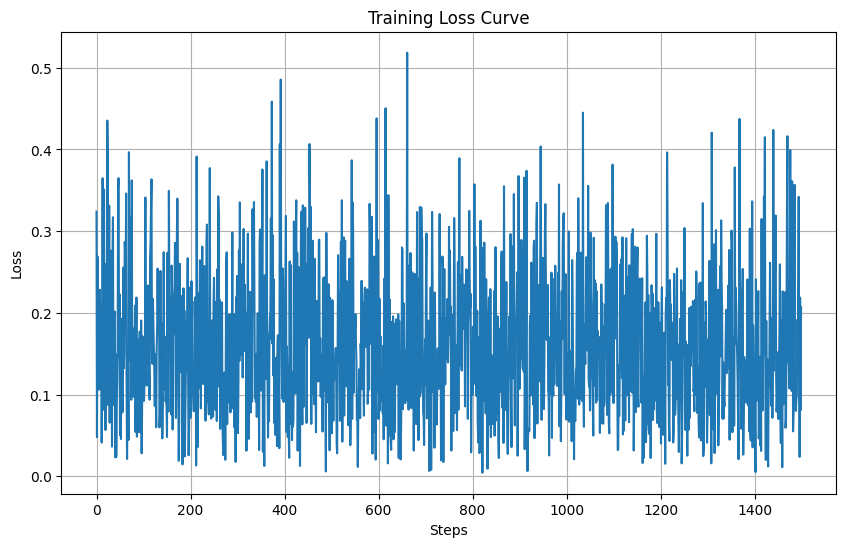

Final Loss: 0.2070
Min Loss: 0.0044 at step 821
Average Loss (first 200 steps): 0.1594
Average Loss (last 200 steps): 0.1594
Average Loss: 0.1617
Improvement: 3.4%
⚠️  Training may need more steps or LR adjustment


In [ ]:
print("\n" + "="*50)
print("📊 TRAINING SUMMARY")
print("="*50)

if loss_history:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.plot(loss_history)
    plt.title('Training Loss Curve')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curve.png'))
    plt.show()

    print(f"Final Loss: {loss_history[-1]:.4f}")
    print(f"Min Loss: {min(loss_history):.4f} at step {loss_history.index(min(loss_history))}")
    print(f"Average Loss (first 200 steps): {sum(loss_history[-200:])/200:.4f}")
    print(f"Average Loss (last 200 steps): {sum(loss_history[-200:])/200:.4f}")
    print(f"Average Loss: {sum(loss_history[-1500:])/1500:.4f}")

    if len(loss_history) > 200:
        first_100_avg = sum(loss_history[:100])/100
        last_100_avg = sum(loss_history[-100:])/100
        improvement = ((first_100_avg - last_100_avg) / first_100_avg) * 100
        print(f"Improvement: {improvement:.1f}%")

In [ ]:
"""
FID Evaluation Script for Stable Diffusion + LoRA

Function:
- Filters real images to match the caption set.
- Generates synthetic images using either:
  1) Base Stable Diffusion 1.5, or
  2) A chosen LoRA checkpoint.
- Computes FID score using CleanFID between real and generated sets.
- Saves outputs and metrics, including an archive of all results.

To evaluate different LoRA checkpoints:
- Set `lora_weights_path` to any adapter folder, e.g.:
    "./lora_training/lora_output/adapter_step_200"
    "./lora_training/lora_output/adapter_step_500"
    "./lora_training/lora_output/adapter_step_1500"
- Toggle `run_base` and `run_lora` to control which comparisons are executed.
"""

!pip install clean_fid

import os
import json
import shutil
from tqdm import tqdm
import torch
from diffusers import StableDiffusionPipeline, PNDMScheduler
from diffusers.utils import logging
import zipfile
from cleanfid import fid

# --- CONFIG ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5"

# paths
lora_weights_path = "./lora_training/lora_output/adapter_step_200"   # <-- change LoRA checkpoint
captions_file = "elden_captions.json"
real_images_dir = "./eldenring_images"
output_dir = "./results_fid"
os.makedirs(output_dir, exist_ok=True)

guidance = 7.5
steps = 30

logging.set_verbosity_error()

with open(captions_file, "r") as f:
    captions = json.load(f)

filtered_real_dir = os.path.join(output_dir, "real_filtered")
os.makedirs(filtered_real_dir, exist_ok=True)

print("Filtering real images to match captions...")
for fname in captions.keys():
    src_path = os.path.join(real_images_dir, fname)
    dst_path = os.path.join(filtered_real_dir, fname)
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
    else:
        print(f"Missing real image for {fname}, skipping...")

run_base = False
if run_base:
    print("Loading base model...")
    pipe_base = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
    ).to(device)
    pipe_base.scheduler = PNDMScheduler.from_config(pipe_base.scheduler.config)
    pipe_base.safety_checker = None

    base_generated_dir = os.path.join(output_dir, "base_generated")
    os.makedirs(base_generated_dir, exist_ok=True)

    print("Generating Base images...")
    for fname, data in tqdm(captions.items()):
        caption = data + " <elden-ring>"

        real_path = os.path.join(filtered_real_dir, fname)
        if not os.path.exists(real_path):
            continue

        seed = torch.randint(0, 1_000_000, (1,)).item()
        generator = torch.Generator(device).manual_seed(seed)

        gen_base = pipe_base(
            caption,
            guidance_scale=guidance,
            num_inference_steps=steps,
            generator=generator
        ).images[0]

        gen_base.save(os.path.join(base_generated_dir, fname))

    print("Computing FID for Base...")
    fid_base = fid.compute_fid(filtered_real_dir, base_generated_dir)
    print(f"FID (Base vs Real): {fid_base:.4f}")

    stats_file_base = os.path.join(output_dir, "fid_results_base.json")
    with open(stats_file_base, "w") as f:
        json.dump({"FID_Base_vs_Real": fid_base}, f, indent=2)
    print(f"FID results saved to {stats_file_base}")


run_lora = True
if run_lora:
    print("Loading LoRA model...")
    pipe_lora = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
    ).to(device)
    pipe_lora.scheduler = PNDMScheduler.from_config(pipe_lora.scheduler.config)
    pipe_lora.load_lora_weights(lora_weights_path)
    pipe_lora.safety_checker = None

    lora_generated_dir = os.path.join(output_dir, "lora_generated_step200")
    os.makedirs(lora_generated_dir, exist_ok=True)

    print("Generating LoRA images...")
    for fname, data in tqdm(captions.items()):
        caption = data + " <elden-ring>"

        real_path = os.path.join(filtered_real_dir, fname)
        if not os.path.exists(real_path):
            continue

        seed = torch.randint(0, 1_000_000, (1,)).item()
        generator = torch.Generator(device).manual_seed(seed)

        gen_lora = pipe_lora(
            caption,
            guidance_scale=guidance,
            num_inference_steps=steps,
            generator=generator
        ).images[0]

        gen_lora.save(os.path.join(lora_generated_dir, fname))

    print("Computing FID for LoRA...")
    fid_lora = fid.compute_fid(filtered_real_dir, lora_generated_dir)
    print(f"FID (LoRA vs Real): {fid_lora:.4f}")

    stats_file_lora = os.path.join(output_dir, "fid_results_lora_step200.json")
    with open(stats_file_lora, "w") as f:
        json.dump({"FID_LoRA_step200_vs_Real": fid_lora}, f, indent=2)
    print(f"FID results saved to {stats_file_lora}")


print("Zipping results...")
zip_path = output_dir + ".zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, output_dir))

print(f"All results zipped at {zip_path}")

🧹 Filtering real images to match captions...
⚠️ Missing real image for Bayle_the_Dread.jpg, skipping...
⚠️ Missing real image for Flying_Dragon_Agheel.jpg, skipping...
🔄 Loading LoRA model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

🎨 Generating LoRA images...


  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

📊 Computing FID for LoRA...
compute FID between two folders
Found 104 images in the folder ./results_fid/real_filtered


FID real_filtered : 100%|██████████| 4/4 [00:14<00:00,  3.57s/it]


Found 104 images in the folder ./results_fid/lora_generated_step200


FID lora_generated_step200 : 100%|██████████| 4/4 [00:07<00:00,  1.82s/it]


✅ FID (LoRA vs Real): 213.8312
📁 FID results saved to ./results_fid/fid_results_lora_step200.json
📦 Zipping results...
✅ All results zipped at ./results_fid.zip


In [ ]:
import os
import json
import gc
import random
import logging
from typing import Dict, List
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

try:
    from transformers import CLIPTokenizer, CLIPTextModel, CLIPTextModelWithProjection
    from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
    from diffusers.utils import check_min_version, is_xformers_available
    from diffusers.models.attention_processor import AttnProcessor2_0
    from peft import LoraConfig, get_peft_model
    from accelerate import Accelerator
except ImportError as e:
    raise ImportError(f"Required dependency missing: {e}. Please install: pip install -U transformers diffusers peft accelerate")

check_min_version("0.30.0")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

MODEL_NAME = "stabilityai/stable-diffusion-xl-base-1.0"
IMAGE_DIR = "./eldenring_images"
CAPTION_JSON = "./elden_captions.json"
OUTPUT_DIR = "./lora_output"
TRIGGER_TOKEN = "<elden-ring>"

RESOLUTION = 512
MAX_TRAIN_STEPS = 1500
EPOCHS = 30
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 4
LEARNING_RATE = 5e-4
LORA_RANK = 32
SAVE_STEPS = [200, 500, 1000, 1500]
SEED = 42
TRAIN_TEXT_ENCODERS = True
USE_FP16_SAFE_VAE = True
MIXED_PRECISION = "fp16"

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Image directory {IMAGE_DIR} does not exist.")
if not os.path.exists(CAPTION_JSON):
    raise FileNotFoundError(f"Caption JSON file {CAPTION_JSON} does not exist.")

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(SEED)
torch.manual_seed(SEED)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger("sdxl_lora")

# Dataset
class JsonCaptionDataset(Dataset):
    def __init__(self, image_dir: str, captions_json: str, tokenizer1, tokenizer2, resolution: int):
        with open(captions_json, "r", encoding="utf-8") as f:
            caps: Dict[str, str] = json.load(f)

        all_names = [n for n in os.listdir(image_dir) if n in caps and caps[n].strip()]
        all_names.sort()
        self.names = all_names
        self.image_dir = image_dir
        self.caps = {n: caps[n] for n in self.names}
        if not self.names:
            raise ValueError("No valid images with non-empty captions found.")
        logger.info(f"Loaded {len(self.names)} images with valid captions.")
        if len(self.names) < 100:
            logger.warning("Small dataset size may lead to overfitting. Consider adding more images.")

        self.tok1 = tokenizer1
        self.tok2 = tokenizer2

        self.tf = transforms.Compose([
            transforms.Resize((resolution, resolution), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.names)

    def __getitem__(self, i):
        name = self.names[i]
        path = os.path.join(self.image_dir, name)
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            logger.error(f"Failed to load image {name}: {e}")
            img = Image.new("RGB", (RESOLUTION, RESOLUTION), (255, 255, 255))
        img = self.tf(img)

        caption = (self.caps[name] or "").strip()
        if TRIGGER_TOKEN not in caption:
            caption = (caption + " " + TRIGGER_TOKEN).strip()

        t1 = self.tok1(caption, padding="max_length", truncation=True,
                       max_length=self.tok1.model_max_length, return_tensors="pt")
        t2 = self.tok2(caption, padding="max_length", truncation=True,
                       max_length=self.tok2.model_max_length, return_tensors="pt")

        return {
            "pixel_values": img,
            "input_ids1": t1.input_ids[0],
            "attention_mask1": t1.attention_mask[0],
            "input_ids2": t2.input_ids[0],
            "attention_mask2": t2.attention_mask[0],
            "name": name
        }

logger.info("Loading tokenizers...")
tokenizer1 = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer")
tokenizer2 = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer_2")

num_added_tokens = tokenizer1.add_tokens([TRIGGER_TOKEN])
if num_added_tokens == 0:
    raise ValueError(f"The tokenizer already contains the token {TRIGGER_TOKEN}. Please pass a different one.")
tokenizer2.add_tokens([TRIGGER_TOKEN])

logger.info("Loading text encoders...")
text_encoder1 = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder="text_encoder")
text_encoder2 = CLIPTextModelWithProjection.from_pretrained(MODEL_NAME, subfolder="text_encoder_2")

text_encoder1.resize_token_embeddings(len(tokenizer1))
text_encoder2.resize_token_embeddings(len(tokenizer2))

logger.info("Loading VAE...")
if USE_FP16_SAFE_VAE:
    vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix")
else:
    vae = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder="vae")
vae.requires_grad_(False)
vae.enable_slicing()
vae.enable_tiling()

logger.info("Loading UNet...")
unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder="unet")

unet.enable_gradient_checkpointing()
if is_xformers_available():
    try:
        unet.enable_xformers_memory_efficient_attention()
    except Exception:
        unet.set_attn_processor(AttnProcessor2_0())
else:
    unet.set_attn_processor(AttnProcessor2_0())

unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
)
unet = get_peft_model(unet, unet_lora_config)

if TRAIN_TEXT_ENCODERS:
    te_lora_config = LoraConfig(
        r=LORA_RANK,
        lora_alpha=LORA_RANK,
        init_lora_weights="gaussian",
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
    )
    text_encoder1 = get_peft_model(text_encoder1, te_lora_config)
    text_encoder2 = get_peft_model(text_encoder2, te_lora_config)
    try:
        text_encoder1.gradient_checkpointing_enable()
        text_encoder2.gradient_checkpointing_enable()
    except Exception:
        pass
else:
    text_encoder1.requires_grad_(False)
    text_encoder2.requires_grad_(False)

trainable_params = [p for p in unet.parameters() if p.requires_grad]
if TRAIN_TEXT_ENCODERS:
    trainable_params += [p for p in text_encoder1.parameters() if p.requires_grad]
    trainable_params += [p for p in text_encoder2.parameters() if p.requires_grad]
logger.info(f"Trainable params: {sum(p.numel() for p in trainable_params):,}")

optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE)
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_NAME, subfolder="scheduler")

from torch.optim.lr_scheduler import OneCycleLR
lr_scheduler = OneCycleLR(optimizer, max_lr=LEARNING_RATE, epochs=EPOCHS, steps_per_epoch=max(1, (len(os.listdir(IMAGE_DIR)) // BATCH_SIZE)))

accelerator = Accelerator(gradient_accumulation_steps=GRAD_ACCUM_STEPS, mixed_precision=MIXED_PRECISION)
device = accelerator.device

dataset = JsonCaptionDataset(IMAGE_DIR, CAPTION_JSON, tokenizer1, tokenizer2, RESOLUTION)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

dataloader, unet, text_encoder1, text_encoder2, optimizer = accelerator.prepare(
    dataloader, unet, text_encoder1, text_encoder2, optimizer
)

vae_dtype = torch.float16 if USE_FP16_SAFE_VAE else torch.float32
vae = vae.to(device, dtype=vae_dtype)

unet.train()
text_encoder1.train()
text_encoder2.train()

@torch.no_grad()
def get_sdxl_conds(input_ids1, attn1, input_ids2, attn2, target_device, dtype):
    enc1 = text_encoder1(input_ids=input_ids1, attention_mask=attn1, output_hidden_states=True)
    enc2 = text_encoder2(input_ids=input_ids2, attention_mask=attn2, output_hidden_states=True)

    prompt_embeds = torch.cat([enc1.hidden_states[-2], enc2.hidden_states[-2]], dim=-1)
    pooled_embeds = enc2.text_embeds
    prompt_embeds = prompt_embeds.to(target_device, dtype=dtype)
    pooled_embeds = pooled_embeds.to(target_device, dtype=dtype)
    del enc1, enc2

    add_time_ids = torch.tensor(
        [RESOLUTION, RESOLUTION, 0, 0, RESOLUTION, RESOLUTION],
        device=target_device, dtype=dtype
    ).unsqueeze(0).repeat(prompt_embeds.size(0), 1)
    return prompt_embeds, pooled_embeds, add_time_ids

def save_lora(tag: str):
    with torch.no_grad():
        unet.eval()
        if TRAIN_TEXT_ENCODERS:
            text_encoder1.eval()
            text_encoder2.eval()

        save_path = os.path.join(OUTPUT_DIR, f"lora_{tag}")
        os.makedirs(save_path, exist_ok=True)

        unet_to_save = accelerator.unwrap_model(unet)
        unet_to_save.save_pretrained(os.path.join(save_path, "unet"))

        if TRAIN_TEXT_ENCODERS:
            te1_to_save = accelerator.unwrap_model(text_encoder1)
            te2_to_save = accelerator.unwrap_model(text_encoder2)
            te1_to_save.save_pretrained(os.path.join(save_path, "text_encoder"))
            te2_to_save.save_pretrained(os.path.join(save_path, "text_encoder_2"))

        torch.cuda.empty_cache()
        gc.collect()

        unet.train()
        if TRAIN_TEXT_ENCODERS:
            text_encoder1.train()
            text_encoder2.train()

    logger.info(f"LoRA adapters saved at {save_path}")

global_step = 0
loss_history: List[float] = []
logger.info("Starting training...")

for epoch in range(EPOCHS):
    for batch_idx, batch in enumerate(dataloader):
        if global_step >= MAX_TRAIN_STEPS:
            break

        with accelerator.accumulate(unet):
            pixel_values = batch["pixel_values"].to(device, dtype=vae_dtype)
            with torch.no_grad():
                latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor

            latents = latents.to(device, dtype=torch.float16)
            noise = torch.randn_like(latents)
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],), device=device, dtype=torch.long
            )
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            input_ids1 = batch["input_ids1"].to(device)
            attn1 = batch["attention_mask1"].to(device)
            input_ids2 = batch["input_ids2"].to(device)
            attn2 = batch["attention_mask2"].to(device)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(MIXED_PRECISION == "fp16")):
                prompt_embeds, pooled, add_time_ids = get_sdxl_conds(
                    input_ids1, attn1, input_ids2, attn2,
                    target_device=device, dtype=torch.float16
                )
                model_out = unet(
                    noisy_latents, timesteps,
                    encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs={"text_embeds": pooled, "time_ids": add_time_ids},
                )
                pred = model_out.sample
                loss = F.mse_loss(pred, noise, reduction="mean")

            accelerator.backward(loss)

        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or (batch_idx + 1) == len(dataloader):
            accelerator.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
            current_lr = optimizer.param_groups[0]["lr"]
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        else:
            current_lr = optimizer.param_groups[0]["lr"]

        loss_value = float(loss.detach().cpu().item())
        loss_history.append(loss_value)

        global_step += 1

        print(f"Step {global_step} | Loss={loss_value:.6f} | LR={current_lr:.4e}")

        del pixel_values, latents, noisy_latents, noise, pred, prompt_embeds, pooled, add_time_ids
        torch.cuda.empty_cache()
        gc.collect()

        if global_step in SAVE_STEPS:
            save_lora(f"step_{global_step}")

        if global_step >= MAX_TRAIN_STEPS:
            break

    if global_step >= MAX_TRAIN_STEPS:
        break

logger.info("Training complete. Saving final LoRA...")
save_lora("final")

logger.info("Loss history (sampled every 50 steps):")
for i, loss_val in enumerate(loss_history):
    if i % 50 == 0 or i == len(loss_history) - 1:
        logger.info(f"Step {i+1}: Loss = {loss_val:.6f}")

loss_history_path = os.path.join(OUTPUT_DIR, "loss_history.json")
with open(loss_history_path, "w") as f:
    json.dump(loss_history, f, indent=2)
logger.info(f"Loss history saved to: {loss_history_path}")

import zipfile
import shutil
from google.colab import files

def create_and_download_zip():
    """Create a zip file of the output directory and download it"""
    zip_filename = f"lora_training_results_{global_step}_steps.zip"

    logger.info(f"Creating zip file: {zip_filename}")

    # Create zip file
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files_list in os.walk(OUTPUT_DIR):
            for file in files_list:
                file_path = os.path.join(root, file)
                # Add file to zip with relative path
                arcname = os.path.relpath(file_path, OUTPUT_DIR)
                zipf.write(file_path, arcname)

    logger.info(f"Zip file created: {zip_filename}")

    try:
        files.download(zip_filename)
        logger.info("Download started! Check your browser downloads.")
    except Exception as e:
        logger.warning(f"Could not auto-download in this environment: {e}")
        logger.info(f"Zip file saved as: {zip_filename}")

create_and_download_zip()

print(f"Training complete!")
print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Loss history saved to: {loss_history_path}")
print(f"LoRA adapters saved to: {OUTPUT_DIR}")
print(f"Checkpoints saved at steps: {SAVE_STEPS}")
print(f"Results zip file has been created and download should start automatically!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step 1 | Loss=0.433573 | LR=2.0000e-05
Step 2 | Loss=0.078138 | LR=2.0000e-05
Step 3 | Loss=0.410343 | LR=2.0000e-05
Step 4 | Loss=0.024665 | LR=2.0000e-05
Step 5 | Loss=0.017010 | LR=2.0001e-05
Step 6 | Loss=0.333747 | LR=2.0001e-05
Step 7 | Loss=0.061343 | LR=2.0001e-05
Step 8 | Loss=0.291520 | LR=2.0001e-05
Step 9 | Loss=0.004986 | LR=2.0004e-05
Step 10 | Loss=0.349089 | LR=2.0004e-05
Step 11 | Loss=0.363467 | LR=2.0004e-05
Step 12 | Loss=0.365975 | LR=2.0004e-05
Step 13 | Loss=0.397263 | LR=2.0009e-05
Step 14 | Loss=0.022284 | LR=2.0009e-05
Step 15 | Loss=0.125106 | LR=2.0009e-05
Step 16 | Loss=0.220260 | LR=2.0009e-05
Step 17 | Loss=0.283203 | LR=2.0017e-05
Step 18 | Loss=0.201075 | LR=2.0017e-05
Step 19 | Loss=0.003224 | LR=2.0017e-05
Step 20 | Loss=0.059810 | LR=2.0017e-05
Step 21 | Loss=0.020911 | LR=2.0026e-05
Step 22 | Loss=0.259601 | LR=2.0026e-05
Step 23 | Loss=0.017384 | LR=2.0026e-05
Step 24 | Loss=0.133919 | LR=2.0026e-05
Step 25 | Loss=0.008717 | LR=2.0038e-05
Step 26 |

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Training complete!
📊 Final loss: 0.121828
📈 Loss history saved to: ./lora_output/loss_history.json
💾 LoRA adapters saved to: ./lora_output
🔍 Checkpoints saved at steps: [200, 500, 1000, 1500]
📦 Results zip file has been created and download should start automatically!


Loaded 1500 loss values from loss_history.json

📊 TRAINING SUMMARY


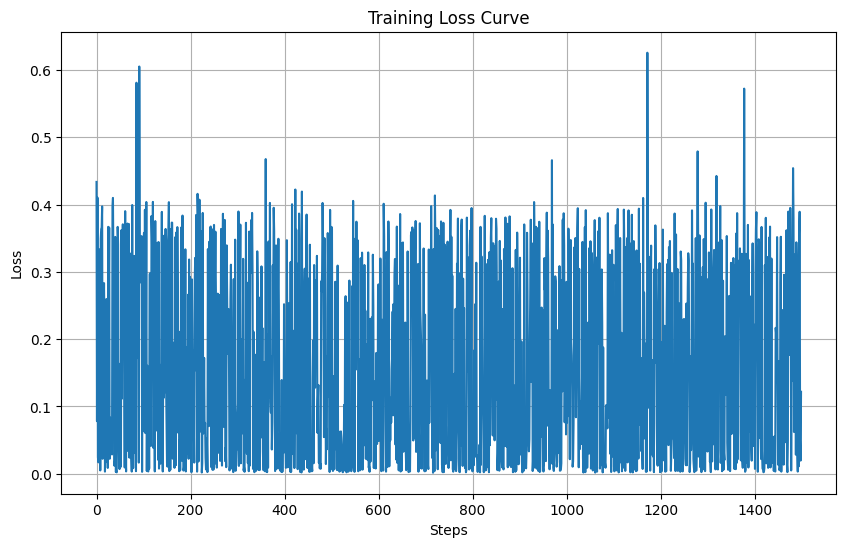

Final Loss: 0.1218
Min Loss: 0.0016 at step 716
Average Loss (first 200 steps): 0.1798
Average Loss (last 200 steps): 0.1605
Average Loss (full): 0.1549
Improvement: 16.9%
⚠️  Training may need more steps or LR adjustment


In [ ]:
import os
import json
import matplotlib.pyplot as plt

LOSS_JSON_PATH = "loss_history.json"
OUTPUT_DIR = "./training_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(LOSS_JSON_PATH, "r") as f:
    loss_history = json.load(f)

print(f"Loaded {len(loss_history)} loss values from {LOSS_JSON_PATH}")

print("\n" + "="*50)
print("📊 TRAINING SUMMARY")
print("="*50)

if loss_history:

    plt.figure(figsize=(10, 6))
    plt.plot(loss_history)
    plt.title('Training Loss Curve')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curve.png'))
    plt.show()

    print(f"Final Loss: {loss_history[-1]:.4f}")
    print(f"Min Loss: {min(loss_history):.4f} at step {loss_history.index(min(loss_history))}")

    first_200 = loss_history[:200] if len(loss_history) >= 200 else loss_history
    last_200 = loss_history[-200:] if len(loss_history) >= 200 else loss_history

    print(f"Average Loss (first 200 steps): {sum(first_200)/len(first_200):.4f}")
    print(f"Average Loss (last 200 steps): {sum(last_200)/len(last_200):.4f}")
    print(f"Average Loss (full): {sum(loss_history)/len(loss_history):.4f}")

    if len(loss_history) > 200:
        first_100_avg = sum(loss_history[:100])/100
        last_100_avg = sum(loss_history[-100:])/100
        improvement = ((first_100_avg - last_100_avg) / frst_100_avg) * 100
        print(f"Improvement: {improvement:.1f}%")


In [ ]:
#FID SCORE CALCULATION FOR BASE SDXL
!pip install clean-fid

import os
import json
import shutil
from tqdm import tqdm
import torch
from diffusers import StableDiffusionXLPipeline, EulerDiscreteScheduler
from diffusers.utils import logging
from cleanfid import fid
import zipfile

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "stabilityai/stable-diffusion-xl-base-1.0"

captions_file = "elden_captions.json"
real_images_dir = "./eldenring_images"
output_dir = "./results_fid_sdxl"
os.makedirs(output_dir, exist_ok=True)

guidance = 10
steps = 50
resolution = 512
SEED = 42

logging.set_verbosity_error()

MAX_TOKENS = 77
STYLE_TOKEN = "<elden-ring>"
def truncate_prompt(prompt, max_tokens=MAX_TOKENS, style_token=STYLE_TOKEN):
    prompt = prompt.strip()

    prompt = prompt.replace(style_token, "").strip()
    prompt = prompt + " " + style_token

    words = prompt.split()
    if len(words) > max_tokens:
        words = words[:max_tokens-1] + [style_token]

    return " ".join(words)

with open(captions_file, "r") as f:
    captions = json.load(f)

filtered_real_dir = os.path.join(output_dir, "real_filtered")
os.makedirs(filtered_real_dir, exist_ok=True)

print("Filtering real images to match captions...")
for fname in captions.keys():
    src_path = os.path.join(real_images_dir, fname)
    dst_path = os.path.join(filtered_real_dir, fname)
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)


print("Loading SDXL model...")
pipe_sdxl = StableDiffusionXLPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
).to(device)

pipe_sdxl.scheduler = EulerDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")
pipe_sdxl.enable_model_cpu_offload()

sdxl_generated_dir = os.path.join(output_dir, "sdxl_generated")
os.makedirs(sdxl_generated_dir, exist_ok=True)

fixed_generator = torch.Generator(device).manual_seed(SEED)

print("Generating SDXL Base images with FIXED SEED + TRUNCATED PROMPTS...")
for fname, data in tqdm(captions.items()):
    caption = truncate_prompt(data)

    real_path = os.path.join(filtered_real_dir, fname)
    if not os.path.exists(real_path):
        continue

    image = pipe_sdxl(
        caption,
        guidance_scale=guidance,
        num_inference_steps=steps,
        generator=fixed_generator,
        height=resolution,
        width=resolution
    ).images[0]

    image.save(os.path.join(sdxl_generated_dir, fname))

print("Computing FID for SDXL Base...")
fid_sdxl = fid.compute_fid(filtered_real_dir, sdxl_generated_dir)
print(f"FID (SDXL Base vs Real): {fid_sdxl:.4f}")

with open(os.path.join(output_dir, "fid_results_sdxl_base.json"), "w") as f:
    json.dump({"FID_SDXL_Base_vs_Real": fid_sdxl}, f, indent=2)

zip_path = output_dir + ".zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), output_dir))

print(f"All results zipped at {zip_path}")


🧹 Filtering real images to match captions...
🔄 Loading SDXL model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

...

📊 Computing FID for SDXL Base...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


compute FID between two folders
Found 106 images in the folder ./results_fid_sdxl/real_filtered


FID real_filtered :   0%|          | 0/4 [00:00<?, ?it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79adc7bd3ec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1628, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in sel

KeyboardInterrupt: 

In [ ]:
#FID SCORE CALCULATION FOR LORA SDXL
#SET OUTPUT_DIR AND LORA_DIR TO DESIRED LOCATIONS (LORA_DIR IS THE DIR WHERE THE CHECKPOINT IS SAVED)

import os
import json
import torch
from PIL import Image
from diffusers import StableDiffusionXLPipeline, AutoencoderKL, EulerDiscreteScheduler, UNet2DConditionModel
from transformers import CLIPTokenizer, CLIPTextModel, CLIPTextModelWithProjection
from peft import PeftModel
from diffusers.utils import is_xformers_available
from cleanfid import fid

MODEL_NAME = "stabilityai/stable-diffusion-xl-base-1.0"
LORA_DIR = "./lora_step_200"
TRIGGER_TOKEN = "<elden-ring>"
OUTPUT_DIR = "./results_fid_sdxl/lora_inference_output_200"
captions_file = "elden_captions.json"
real_images_dir = "./eldenring_images"
SEED = 42

NUM_INFERENCE_STEPS = 50
GUIDANCE_SCALE = 10
RESOLUTION = 512

os.makedirs(OUTPUT_DIR, exist_ok=True)
torch.manual_seed(SEED)

MAX_TOKENS = 77
STYLE_TOKEN = "<elden-ring>"

tokenizer_temp = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer")

def truncate_prompt(prompt, max_tokens=MAX_TOKENS, style_token=STYLE_TOKEN, tokenizer=tokenizer_temp):
    if style_token not in prompt:
        prompt = prompt.strip() + " " + style_token

    encoded = tokenizer(prompt, truncation=False, add_special_tokens=True)
    ids = encoded["input_ids"]

    if len(ids) <= max_tokens:
        return prompt

    style_id = tokenizer.convert_tokens_to_ids(style_token)
    body = ids[:max_tokens - 2]  # leave space for style + EOS
    new_ids = body + [style_id, tokenizer.eos_token_id]

    return tokenizer.decode(new_ids, skip_special_tokens=True)

with open(captions_file, "r", encoding="utf-8") as f:
    captions = {fname: truncate_prompt(text) for fname, text in json.load(f).items()}

tokenizer1 = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer")
tokenizer2 = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer_2")
tokenizer1.add_tokens([TRIGGER_TOKEN])
tokenizer2.add_tokens([TRIGGER_TOKEN])

text_encoder1 = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder="text_encoder", torch_dtype=torch.float16)
text_encoder2 = CLIPTextModelWithProjection.from_pretrained(MODEL_NAME, subfolder="text_encoder_2", torch_dtype=torch.float16)
text_encoder1.resize_token_embeddings(len(tokenizer1))
text_encoder2.resize_token_embeddings(len(tokenizer2))

unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder="unet", torch_dtype=torch.float16)
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
vae.enable_slicing()
vae.enable_tiling()

scheduler = EulerDiscreteScheduler.from_pretrained(MODEL_NAME, subfolder="scheduler")

unet = PeftModel.from_pretrained(unet, os.path.join(LORA_DIR, "unet"), torch_dtype=torch.float16).merge_and_unload()
text_encoder1 = PeftModel.from_pretrained(text_encoder1, os.path.join(LORA_DIR, "text_encoder"), torch_dtype=torch.float16).merge_and_unload()
text_encoder2 = PeftModel.from_pretrained(text_encoder2, os.path.join(LORA_DIR, "text_encoder_2"), torch_dtype=torch.float16).merge_and_unload()

pipeline = StableDiffusionXLPipeline(
    vae=vae,
    text_encoder=text_encoder1,
    text_encoder_2=text_encoder2,
    tokenizer=tokenizer1,
    tokenizer_2=tokenizer2,
    unet=unet,
    scheduler=scheduler,
)

pipeline.safety_checker = None

if is_xformers_available():
    pipeline.enable_xformers_memory_efficient_attention()

pipeline = pipeline.to("cuda", dtype=torch.float16)

print(f"Generating {len(captions)} images...")

for idx, (filename, prompt) in enumerate(captions.items(), start=1):
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        image = pipeline(
            prompt=prompt,
            negative_prompt="distorted, blurry, low quality, artifacts",
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            generator=torch.Generator(device="cuda").manual_seed(SEED + idx),
            height=RESOLUTION,
            width=RESOLUTION,
        ).images[0]

    output_path = os.path.join(OUTPUT_DIR, filename)
    image.save(output_path)
    print(f"Saved: {output_path}")

print("Calculating FID...")
fid_score = fid.compute_fid(
    fdir1=real_images_dir,
    fdir2=OUTPUT_DIR,
    mode="clean"
)
print(f"✅ FID (LoRA step 1000 vs Real): {fid_score}")

del pipeline, unet, vae, text_encoder1, text_encoder2
torch.cuda.empty_cache()
print(f"✅ LoRA inference complete. Images saved in: {OUTPUT_DIR}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (87 > 77). Running this sequence through the model will result in indexing errors
`torch_dtype` is deprecated! Use `dtype` instead!
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False

Generating 106 images...


  0%|          | 0/50 [00:00<?, ?it/s]

Saved: ./results_fid_sdxl/lora_inference_output_200/Crucible_Knight_Siluria.jpg


  0%|          | 0/50 [00:00<?, ?it/s]

...

compute FID between two folders
Found 118 images in the folder ./eldenring_images


FID eldenring_images : 100%|██████████| 4/4 [00:17<00:00,  4.50s/it]


Found 106 images in the folder ./results_fid_sdxl/lora_inference_output_200


FID lora_inference_output_200 : 100%|██████████| 4/4 [00:07<00:00,  1.80s/it]


✅ FID (LoRA step 1000 vs Real): 259.10774005369024
✅ LoRA inference complete. Images saved in: ./results_fid_sdxl/lora_inference_output_200


In [ ]:
#Calculate FID for all the results collected
from cleanfid import fid

real_images_dir = "./results_fid_sdxl/real_filtered"

output_paths = {
    "LoRA step 1500": "./results_fid_sdxl/lora_inference_output_1500",
    "SDXL Base": "./results_fid_sdxl/sdxl_generated",
    "LoRA step 200": "./results_fid_sdxl/lora_inference_output_200",
    "LoRA step 500": "./results_fid_sdxl/lora_inference_output_500",
    "LoRA step 1000": "./results_fid_sdxl/lora_inference_output_1000",
}

fid_results = {}
for name, out_dir in output_paths.items():
    print(f"Calculating FID for {name}...")
    fid_score = fid.compute_fid(
        fdir1=real_images_dir,
        fdir2=out_dir,
        mode="clean"
    )
    fid_results[name] = fid_score
    print(f"FID ({name} vs Real): {fid_score:.4f}")

import json
with open("fid_results_all.json", "w") as f:
    json.dump(fid_results, f, indent=2)
print("All FID results saved to fid_results_all.json")


Calculating FID for LoRA step 1500...
compute FID between two folders
Found 106 images in the folder ./results_fid_sdxl/real_filtered


FID real_filtered : 100%|██████████| 4/4 [00:14<00:00,  3.69s/it]


Found 106 images in the folder ./results_fid_sdxl/lora_inference_output_1500


FID lora_inference_output_1500 : 100%|██████████| 4/4 [00:07<00:00,  1.89s/it]


✅ FID (LoRA step 1500 vs Real): 206.5144
Calculating FID for SDXL Base...
compute FID between two folders
Found 106 images in the folder ./results_fid_sdxl/real_filtered


...

✅ FID (SDXL Base vs Real): 269.2809
Calculating FID for LoRA step 200...
compute FID between two folders
Found 106 images in the folder ./results_fid_sdxl/real_filtered


FID real_filtered : 100%|██████████| 4/4 [00:12<00:00,  3.22s/it]


Found 106 images in the folder ./results_fid_sdxl/lora_inference_output_200


FID lora_inference_output_200 : 100%|██████████| 4/4 [00:05<00:00,  1.48s/it]


KeyboardInterrupt: 

In [ ]:
"Zips and downloads the sdxl results (the results_fid_sdxl folder)"

import shutil
import os
from google.colab import files

folder_path = "results_fid_sdxl"
zip_name = "results_fid_sdxl.zip"

if not os.path.exists(folder_path):
    raise ValueError(f"Folder not found: {folder_path}")

shutil.make_archive(zip_name.replace(".zip", ""), 'zip', folder_path)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>